# NeuroSeek-MoE: ArXiv Healthcare+ML Paper Training Pipeline

Example complete pipeline for training language models on healthcare+ML papers from ArXiv.

**Features:**
- ArXiv paper collection via free ArXiv API
- Direct paper download using NeMo Curator's free download_arxiv() function
- NeMo Curator curation with custom healthcare stages (Linux/Colab only)
- Healthcare-specific preprocessing
- SentencePiece tokenizer training
- Model training with Colab-optimized settings
- Evaluation and inference export

**Requirements:**
- NeMo Curator: Requires Linux (On non-Linux platforms, the pipeline falls back to basic preprocessing.)



Original repository: https://github.com/oleeveeuh/neuroSeekMOE.git

## Notes

- I used Google Drive backups in case the Colab session disconnects during data processing or training. Model checkpoints are saved every 5000 steps and can be resumed from the latest checkpoint.

## Troubleshooting

- Out of Memory: Reduce `batch_size` or `max_papers` in config.yaml
- Interrupted Training: Use the resume feature (Step 5) to continue from the last checkpoint

## 1. Setup Environment


In [1]:
# Mount Google Drive (optional - for persistent storage)
from google.colab import drive
drive.mount('/content/drive')

# Set working directory
import os
WORK_DIR = '/content/neuroMOE'
os.makedirs(WORK_DIR, exist_ok=True)
os.chdir(WORK_DIR)
print(f"Working directory: {WORK_DIR}")


Mounted at /content/drive
Working directory: /content/neuroMOE


In [2]:
# Install dependencies
print("Installing dependencies...")

# Core dependencies
!pip install -q deepspeed arxiv PyPDF2 sentencepiece pyyaml scikit-learn matplotlib pandas

# PyTorch (Colab usually has it, but ensure it's available)
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# NeMo Curator (Linux/Colab only)
import platform
if platform.system() == 'Linux':
    print(" Linux detected - installing NeMo Curator...")
    try:
        # Install NeMo Curator with text support
        !pip install -q "nemo-curator[text_cuda12]"

        print("NeMo Curator installed")


    except Exception as e:
        print(f"NeMo Curator installation failed: {e}")
        print("   Pipeline will use fallback preprocessing")
else:
    print("Non-Linux system - NeMo Curator not available")
    print("   Pipeline will use fallback preprocessing")

print("Dependencies installed")


Installing dependencies...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 14.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 17.9 MB/s eta 0:00:00
 Linux detected - installing NeMo Curator...
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.1/98.1 kB 6.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyp

### Restore Data and Checkpoints from Google Drive

If you have previously saved data and checkpoints to Google Drive, restore them here to resume your pipeline.

In [6]:
# Clone repository from GitHub
import sys
import subprocess
import os
import shutil # Import shutil for directory operations

# Update this URL to your repository
REPO_URL = "https://github.com/oleeveeuh/neuroseekmoe.git"

# Clone the repository
if not os.path.exists(os.path.join(WORK_DIR, ".git")):
    print(f" Cloning repository from {REPO_URL}...")
    # Ensure WORK_DIR is empty before cloning, as 'git clone .' fails on non-empty dirs.
    # This specifically addresses the 'exit status 128' error when target dir is not empty.
    if os.listdir(WORK_DIR): # Check if WORK_DIR contains any files/subdirs
        print(f"   Warning: {WORK_DIR} is not empty. Clearing contents before cloning...")
        for item in os.listdir(WORK_DIR):
            item_path = os.path.join(WORK_DIR, item)
            if os.path.isdir(item_path):
                shutil.rmtree(item_path) # Remove directory and its contents
            else:
                os.remove(item_path) # Remove file
    subprocess.run(["git", "clone", REPO_URL, "."], cwd=WORK_DIR, check=True)
    print("Repository cloned successfully")
else:
    print("Repository already exists. Ensuring clean state and pulling latest changes...")
    # Discard any local changes that might prevent pulling
    subprocess.run(["git", "reset", "--hard"], cwd=WORK_DIR, check=True)
    # Pull the latest changes
    subprocess.run(["git", "pull"], cwd=WORK_DIR, check=True)
    print("Repository updated successfully")

# Add to path
if WORK_DIR not in sys.path:
    sys.path.insert(0, WORK_DIR)

# Verify essential files exist
required_files = ['data_pipeline.py', 'run_pipeline.py', 'config.yaml', 'train_colab.py']
missing_files = [f for f in required_files if not os.path.exists(os.path.join(WORK_DIR, f))]

if missing_files:
    print(f"Warning: Missing files: {', '.join(missing_files)}")
    print("   Please check the repository URL and ensure all files are present")
else:
    print("All required files present")

Repository already exists. Ensuring clean state and pulling latest changes...
Repository updated successfully
All required files present


## 2. Configure Pipeline


In [7]:
# Check if config.yaml exists, create/update if needed
import yaml
import platform

config_path = 'config.yaml'

if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    print("Loaded existing config.yaml")
else:
    print("config.yaml not found, using defaults")
    config = None

# Adjust config for Colab environment
if config:
    # Colab-optimized settings
    DRIVE_BACKUP_PATH = '/content/drive/MyDrive/neuroMOE_results'
    config['pipeline']['output_dir'] = './data/arxiv'
    config['training']['checkpoint_dir'] = './checkpoints'
    config['evaluation']['output_dir'] = './evaluations'
    config['inference']['output_dir'] = './inference'

    # Adjust for Colab GPU (T4, ~12GB VRAM)
    config['training']['batch_size'] = 6
    config['training']['gradient_accumulation_steps'] = 4
    config['training']['num_workers'] = 4

    # NeMo Curator settings (only on Linux)
    if platform.system() == 'Linux':
        # Enable new Pipeline API (recommended)
        config['nemo_curator']['use_pipeline_api'] = True
        config['nemo_curator']['download_dir'] = './data/arxiv/arxiv_downloads'
        config['nemo_curator']['record_limit'] = 3000
        print("NeMo Curator Pipeline API enabled (FREE - no AWS needed)")
    else:
        print("Non-Linux system - NeMo Curator will be skipped")
        # The pipeline will automatically use fallback preprocessing

    # Save updated config
    with open(config_path, 'w') as f:
        yaml.dump(config, f, default_flow_style=False, sort_keys=False)
    print("Config updated for Colab environment")

    # Display key settings
    print("\nKey Configuration:")
    print(f"   Output directory: {config['pipeline']['output_dir']}")
    print(f"   Max papers: {config['collection']['max_papers']}")
    print(f"   Batch size: {config['training']['batch_size']}")
    print(f"   Max steps: {config['training']['max_steps']}")
    print(f"   Learning rate: {config['training']['learning_rate']}")


Loaded existing config.yaml
NeMo Curator Pipeline API enabled (FREE - no AWS needed)
Config updated for Colab environment

Key Configuration:
   Output directory: ./data/arxiv
   Max papers: 50000
   Batch size: 6
   Max steps: 50000
   Learning rate: 5e-4


In [8]:
# Check GPU availability
import torch

if torch.cuda.is_available():
    print(f"GPU available: {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    device = 'cuda'
else:
    print("No GPU available - training will be slow")
    device = 'cpu'

# Set device for PyTorch
torch.cuda.empty_cache() if torch.cuda.is_available() else None


GPU available: Tesla T4
   GPU Memory: 15.83 GB


## 3. Run Data Pipeline


In [9]:
# The variable DRIVE_BACKUP_PATH holds the base path to your Google Drive backup directory.
# We will construct the absolute paths using this variable.

# Input file path
input_file_path = f"{DRIVE_BACKUP_PATH}/data/arxiv/processed_dataset.jsonl"

# Output directory path
output_dir_path = f"{DRIVE_BACKUP_PATH}/data/arxiv/"

# Construct the command using absolute paths
!python data_pipeline.py tokenize --input {input_file_path} --output-dir {output_dir_path}

usage: data_pipeline.py [-h] [--mode {collect,extract,curate,train-tokenizer}]
                        [--output-dir OUTPUT_DIR] [--max-papers MAX_PAPERS]
                        [--input INPUT]
data_pipeline.py: error: unrecognized arguments: tokenize


In [ ]:
!python run_pipeline.py --start-from-step 3

Starting from Step 3: NeMo Curator Curation
2025-12-09 06:11:40,648 - INFO - Output directory: /content/drive/MyDrive/neuroMOE_results/data/arxiv (Google Drive - direct access)
2025-12-09 06:11:40,652 - INFO - Checkpoint directory: /content/drive/MyDrive/neuroMOE_results/checkpoints (Google Drive - direct access)
2025-12-09 06:11:40,652 - INFO - File locations:
2025-12-09 06:11:40,652 - INFO -    Working directory: /content/neuroMOE
2025-12-09 06:11:40,652 - INFO -    Configured output directory: /content/drive/MyDrive/neuroMOE_results/data/arxiv
2025-12-09 06:11:40,652 - INFO -    Metadata file: /content/drive/MyDrive/neuroMOE_results/data/arxiv/arxiv_papers.jsonl
2025-12-09 06:11:40,652 - INFO -    Text directory: /content/drive/MyDrive/neuroMOE_results/data/arxiv/texts
2025-12-09 06:11:40,652 - INFO -    Curated dataset: /content/drive/MyDrive/neuroMOE_results/data/arxiv/curated_dataset.jsonl
2025-12-09 06:11:40,653 - INFO -    Processed dataset: /content/drive/MyDrive/neuroMOE_resu

## 4. Train MoE Model

In [ ]:
# @title

# Input file path
tokenizer_path = f"{DRIVE_BACKUP_PATH}/data/arxiv/healthcare_tokenizer.model"
model_path = f"{DRIVE_BACKUP_PATH}/checkpoints/step_35000.pt"
metadata_path = f"{DRIVE_BACKUP_PATH}/data/arxiv/processed_dataset.jsonl"


# Output directory path
text_path = f"{DRIVE_BACKUP_PATH}/data/arxiv/texts"
output_dir_path = f"{DRIVE_BACKUP_PATH}/checkpoints"


!python train_colab.py \
    --model-path {model_path} \
    --dataset-text-dir {text_path}\
    --dataset-metadata {metadata_path} \
    --tokenizer-path {tokenizer_path} \
    --output-dir {output_dir_path} \
    --batch-size 6 \
    --gradient-accumulation 4 \
    --max-steps 50000

Loaded SentencePiece tokenizer from: /content/drive/MyDrive/neuroMOE_results/data/arxiv/healthcare_tokenizer.model
Loaded SentencePiece tokenizer from: /content/drive/MyDrive/neuroMOE_results/data/arxiv/healthcare_tokenizer.model
   Vocabulary size: 50000
Loading metadata from /content/drive/MyDrive/neuroMOE_results/data/arxiv/processed_dataset.jsonl...
   Loaded 4956 metadata entries
   Found 4956 entries without categories, attempting fallback...
   Found fallback file: /content/drive/MyDrive/neuroMOE_results/data/arxiv/arxiv_papers.jsonl
   Loading categories from /content/drive/MyDrive/neuroMOE_results/data/arxiv/arxiv_papers.jsonl...
   Processed 5002 records from fallback file
   Matched 4956 IDs with metadata
   Found categories in 4956 records
   Loaded categories for 4956 papers from fallback file
ArXivStreamingDataset initialized:
   Text files: 4976
   Metadata entries: 4956
   Max length: 512, Min length: 64
   Shuffle buffer: 100
Created dataset with ~3980 samples
2025-11-

In [ ]:

# Input file path
metadata_path = f"{DRIVE_BACKUP_PATH}/data/arxiv/processed_dataset.jsonl"
tokenizer_path = f"{DRIVE_BACKUP_PATH}/data/arxiv/healthcare_tokenizer.model"


# Output directory path
text_path = f"{DRIVE_BACKUP_PATH}/data/arxiv/texts"
output_dir_path = f"{DRIVE_BACKUP_PATH}/checkpoints/pretrained"

    # --tokenizer-path "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext" \

!python train_colab.py \
    --dataset-text-dir {text_path} \
    --dataset-metadata {metadata_path} \
    --tokenizer-path "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext" \
    --output-dir {output_dir_path} \
    --checkpoint-dir {output_dir_path} \
    --batch-size 6 \
    --gradient-accumulation 4 \
    --max-steps 50000 \
    --learning-rate 5e-4

In [ ]:
# Input file path
tokenizer_path = f"{DRIVE_BACKUP_PATH}/data/arxiv/healthcare_tokenizer.model"
metadata_path = f"{DRIVE_BACKUP_PATH}/data/arxiv/processed_dataset.jsonl"

# Output directory path
text_path = f"{DRIVE_BACKUP_PATH}/data/arxiv/texts"
checkpoint_path = f"{DRIVE_BACKUP_PATH}/checkpoints/step_50000.pt"

output_dir_path = f"{DRIVE_BACKUP_PATH}/evaluations"
    # --tokenizer-path "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext" \


!python evaluate.py \
    --model-checkpoint {checkpoint_path} \
    --dataset-text-dir {text_path} \
    --dataset-metadata {metadata_path} \
    --tokenizer-path {tokenizer_path} \
    --output-dir {output_dir_path}

Streaming output truncated to the last 5000 lines.
  Expert 2 avg prob across all tokens: 0.000122
  Other experts avg prob: 0.000122
  Expert 2 max prob: 0.000372
  Other experts max prob: 0.000492
  Expert 2 selected 4 tokens
  Other experts selected: [4, 4, 4]
  Papers with tokens: [0 2 3 4 5]...
  probs for paper 0: [0.         0.         0.         0.00049162]
  token_counts for paper 0: [0 0 0 1]
  expert_probs_all shape: (4, 8176)
  expert_probs_all sample (expert 0, first 5 tokens): [8.386e-05 3.572e-04 8.386e-05 3.572e-04 5.746e-05]
  Sample token selections:
    Expert 0: selected tokens [1744 6952 1771 6410]
    Expert 1: selected tokens [6133 6131 6157 2128]
    Expert 2: selected tokens [3095 1419 6925 2183]
    Expert 3: selected tokens [2655 7020 5067    0]
  Expert 2 avg prob across all tokens: 0.000122
  Other experts avg prob: 0.000122
  Expert 2 max prob: 0.000372
  Other experts max prob: 0.000492
  Expert 2 selected 4 tokens
  Other experts selected: [4, 4, 4]
  Pa

In [ ]:
tokenizer_path = f"{DRIVE_BACKUP_PATH}/data/arxiv/healthcare_tokenizer.model"
metadata_path = f"{DRIVE_BACKUP_PATH}/data/arxiv/processed_dataset.jsonl"

# Output directory path
text_path = f"{DRIVE_BACKUP_PATH}/data/arxiv/texts"
checkpoint_path = f"{DRIVE_BACKUP_PATH}/checkpoints/step_50000.pt"

output_dir_path = f"{DRIVE_BACKUP_PATH}/evaluations/example_predictions.json"


!python inference.py \
    --checkpoint {checkpoint_path} \
    --tokenizer {tokenizer_path} \
    generate-examples \
    --dataset-metadata {metadata_path} \
    --dataset-text-dir {text_path} \
    --output {output_dir_path} \
    --num-examples 15 \
    --max-input-length 200 \
    --max-prediction-length 50



Loaded SentencePiece tokenizer from: /content/drive/MyDrive/neuroMOE_results/data/arxiv/healthcare_tokenizer.model
Loaded tokenizer (vocab_size=50000)
2025-11-22 06:18:42.031031: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763792322.051176   10146 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763792322.057415   10146 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763792322.073092   10146 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763792322.073119   10146 computation_placer.cc:177] computation placer already registered. Please 

In [ ]:

tokenizer_path = f"{DRIVE_BACKUP_PATH}/data/arxiv/healthcare_tokenizer.model"
metadata_path = f"{DRIVE_BACKUP_PATH}/data/arxiv/processed_dataset.jsonl"

# Output directory path
text_path = f"{DRIVE_BACKUP_PATH}/data/arxiv/texts"
checkpoint_path = f"{DRIVE_BACKUP_PATH}/checkpoints/pretrained/step_50000.pt"

output_dir_path = f"{DRIVE_BACKUP_PATH}/evaluations/pretrained/example_predictions.json"

# Use medical tokenizer in inference

!!python inference.py \
    --checkpoint {checkpoint_path} \
    --tokenizer microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext \
    generate-examples \
    --dataset-metadata {metadata_path} \
    --dataset-text-dir {text_path} \
    --output {output_dir_path} \
    --num-examples 15 \



['Loaded HuggingFace tokenizer: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext',
 'Loaded tokenizer (vocab_size=30522)',
 '2025-11-15 13:25:07.009875: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered',
 'WARNING: All log messages before absl::InitializeLog() is called are written to STDERR',
 'E0000 00:00:1763213107.044100  129066 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered',
 'E0000 00:00:1763213107.054308  129066 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered',
 'W0000 00:00:1763213107.079753  129066 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.',
 'W0000 00:00:17632

##5. Train Baseline Model

In [ ]:
metadata_path = f"{DRIVE_BACKUP_PATH}/data/arxiv/processed_dataset.jsonl"

# Output directory path
text_path = f"{DRIVE_BACKUP_PATH}/data/arxiv/texts"
checkpoint_path = f"{DRIVE_BACKUP_PATH}/checkpoints/baseline"

output_dir_path = f"{DRIVE_BACKUP_PATH}/evaluations/baseline/encoder"

!python train_baseline.py \
    --dataset-text-dir {text_path} \
    --dataset-metadata {metadata_path}\
    --tokenizer-path "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext" \
    --output-dir {output_dir_path} \
    --checkpoint-dir {checkpoint_path} \
    --model-type encoder \
    --batch-size 6 \
    --gradient-accumulation 4 \
    --max-steps 50000 \
    --learning-rate 5e-4

Training Baseline Transformer Model (Encoder-only)

Using device: cuda
tokenizer_config.json: 100% 28.0/28.0 [00:00<00:00, 166kB/s]
config.json: 100% 385/385 [00:00<00:00, 3.82MB/s]
vocab.txt: 226kB [00:00, 57.8MB/s]
Loaded HuggingFace tokenizer: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
✅ Loaded HuggingFace tokenizer: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Loaded tokenizer (vocab_size=30522)
Loading metadata from /content/drive/MyDrive/neuroMOE_results/data/arxiv/processed_dataset.jsonl...
   Loaded 4956 metadata entries
   Found 4956 entries without categories, attempting fallback...
   Found fallback file: /content/drive/MyDrive/neuroMOE_results/data/arxiv/arxiv_papers.jsonl
   Loading categories from /content/drive/MyDrive/neuroMOE_results/data/arxiv/arxiv_papers.jsonl...
   Processed 5002 records from fallback file
   Matched 4956 IDs with metadata
   Found categories in 4956 records
   Loaded categories for 4956 papers from fallback file

In [ ]:
tokenizer_path = f"{DRIVE_BACKUP_PATH}/data/arxiv/healthcare_tokenizer.model"
metadata_path = f"{DRIVE_BACKUP_PATH}/data/arxiv/processed_dataset.jsonl"

# Output directory path
text_path = f"{DRIVE_BACKUP_PATH}/data/arxiv/texts"
checkpoint_path = f"{DRIVE_BACKUP_PATH}/checkpoints/baseline/decoder/baseline_decoder_final.pt"

output_dir_path = f"{DRIVE_BACKUP_PATH}/evaluations/baseline/decoder"

!python evaluate.py \
    --model-checkpoint {checkpoint_path} \
    --dataset-text-dir {text_path} \
    --dataset-metadata {metadata_path} \
    --tokenizer-path "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext" \
    --output-dir {output_dir_path}

Model Evaluation

Loaded HuggingFace tokenizer: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
✅ Loaded HuggingFace tokenizer: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Loaded tokenizer (vocab_size=30522)
Using device: cuda
2025-11-21 23:21:22.836967: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763767282.857193   38830 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763767282.863205   38830 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763767282.878462   38830 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W00

In [ ]:
tokenizer_path = f"{DRIVE_BACKUP_PATH}/data/arxiv/healthcare_tokenizer.model"
metadata_path = f"{DRIVE_BACKUP_PATH}/data/arxiv/processed_dataset.jsonl"

# Output directory path
text_path = f"{DRIVE_BACKUP_PATH}/data/arxiv/texts"
checkpoint_path = f"{DRIVE_BACKUP_PATH}/checkpoints/baseline/encoder/baseline_encoder_final.pt"

output_dir_path = f"{DRIVE_BACKUP_PATH}/evaluations/baseline/encoder/example_predictions.json"

!python inference.py \
    --checkpoint {checkpoint_path} \
    --tokenizer "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext" \
    generate-examples \
    --dataset-metadata {metadata_path} \
    --dataset-text-dir {text_path} \
    --output {output_dir_path} \
    --num-examples 15 \
    --max-input-length 200 \
    --max-prediction-length 50

Loaded HuggingFace tokenizer: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Loaded tokenizer (vocab_size=30522)
2025-11-21 23:29:28.620695: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763767768.641997   41043 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763767768.648105   41043 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763767768.663490   41043 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763767768.663522   41043 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid

## 6. Monitor Progress (Optional)


In [ ]:
# Check pipeline status
import json
from pathlib import Path

report_path = Path('/content/drive/MyDrive/neuroMOE_results/data/arxiv/pipeline_report.json')

if report_path.exists():
    with open(report_path, 'r') as f:
        report = json.load(f)

    print("Pipeline Status Report")
    print("=" * 80)

    # Overall status
    pipeline_info = report.get('pipeline', {})
    print(f"\nTotal elapsed time: {pipeline_info.get('total_elapsed_hours', 0):.2f} hours")

    # Step status
    print("\nStep Status:")
    steps = report.get('steps', {})
    for step_name, step_info in steps.items():
        status = "" if step_info.get('success') else ""
        elapsed = step_info.get('elapsed', 0)
        print(f"   {status} {step_name}: {elapsed:.2f}s")

    # Statistics
    stats = report.get('statistics', {})
    if stats:
        print("\nStatistics:")
        if 'collected_papers' in stats:
            print(f"   Collected papers: {stats['collected_papers']}")
        if 'processed_papers' in stats:
            print(f"   Processed papers: {stats['processed_papers']}")
        if 'checkpoints' in stats:
            print(f"   Checkpoints: {stats['checkpoints']}")
        if 'latest_training_step' in stats:
            print(f"   Latest training step: {stats['latest_training_step']}")
else:
    print("Pipeline report not found. Pipeline may still be running.")


Pipeline Status Report

Total elapsed time: 0.00 hours

Step Status:
    Collect Papers: 0.07s

Statistics:
   Collected papers: 3695
   Processed papers: 6
   Checkpoints: 2
   Latest training step: 50000


Training Progress: 500 log entries


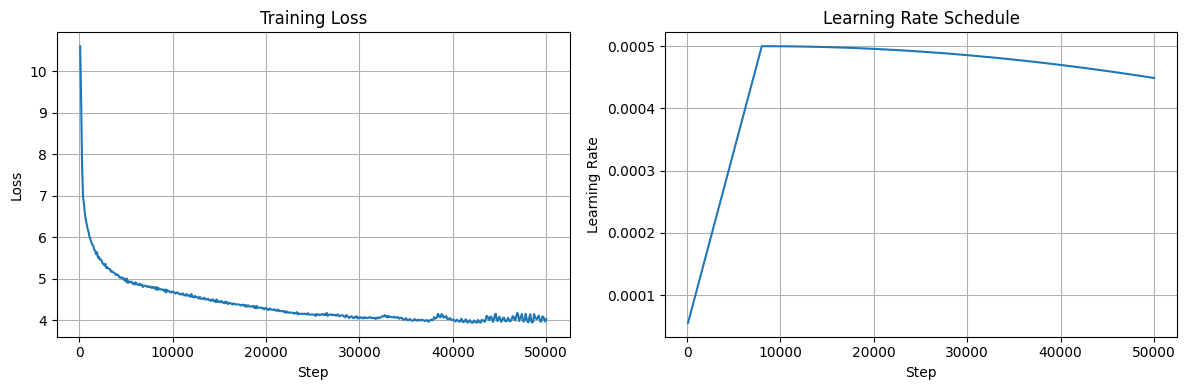


Latest Training Metrics:
   Step: 50000.0
   Loss: 4.0312
   Learning Rate: 0.000449
   GPU Memory: 1347 MB


In [ ]:
# Check training progress (if training has started)
import pandas as pd
import matplotlib.pyplot as plt

log_file = Path('checkpoints/training_log.csv')

if log_file.exists():
    df = pd.read_csv(log_file)

    if len(df) > 0:
        print(f"Training Progress: {len(df)} log entries")

        # Plot loss curve
        if 'loss' in df.columns:
            plt.figure(figsize=(12, 4))

            plt.subplot(1, 2, 1)
            plt.plot(df['step'], df['loss'])
            plt.xlabel('Step')
            plt.ylabel('Loss')
            plt.title('Training Loss')
            plt.grid(True)

            if 'learning_rate' in df.columns:
                plt.subplot(1, 2, 2)
                plt.plot(df['step'], df['learning_rate'])
                plt.xlabel('Step')
                plt.ylabel('Learning Rate')
                plt.title('Learning Rate Schedule')
                plt.grid(True)

            plt.tight_layout()
            plt.show()

            # Display latest metrics
            print("\nLatest Training Metrics:")
            latest = df.iloc[-1]
            print(f"   Step: {latest['step']}")
            print(f"   Loss: {latest['loss']:.4f}")
            if 'learning_rate' in latest:
                print(f"   Learning Rate: {latest['learning_rate']:.6f}")
            if 'gpu_memory_mb' in latest:
                print(f"   GPU Memory: {latest['gpu_memory_mb']:.0f} MB")
    else:
        print("Training log is empty")
else:
    print("Training log not found. Training may not have started yet.")
